# Part A

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
DATA_PATH = "diabetes.csv"  
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [4]:
print("Duplicate rows:", df.duplicated().sum())
print("\nClass balance (Outcome):")
print(df["Outcome"].value_counts())
print(df["Outcome"].value_counts(normalize=True).round(3))

Duplicate rows: 0

Class balance (Outcome):
Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


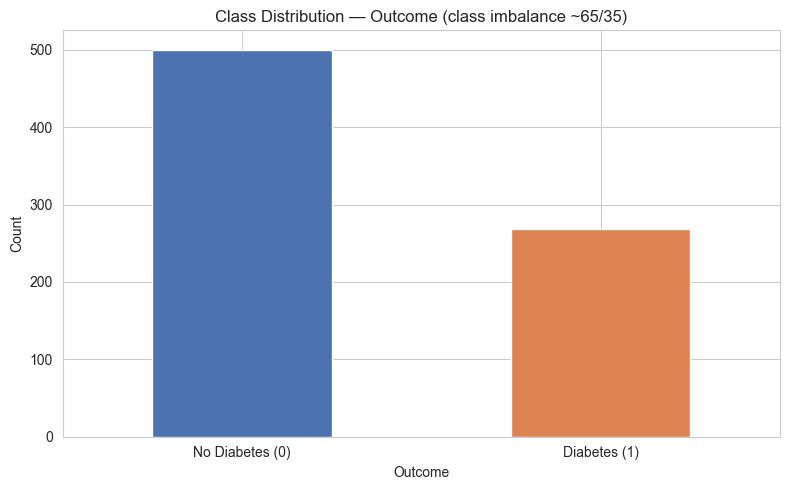

In [5]:
ax = df["Outcome"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
ax.set_xticklabels(["No Diabetes (0)", "Diabetes (1)"], rotation=0)
ax.set_title("Class Distribution — Outcome (class imbalance ~65/35)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [6]:
zero_invalid_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
zero_counts = (df[zero_invalid_cols] == 0).sum()
zero_pct = (zero_counts / len(df) * 100).round(1)
zero_report = pd.DataFrame({"zero_count": zero_counts, "pct_of_rows": zero_pct})
print(zero_report)

               zero_count  pct_of_rows
Glucose                 5          0.7
BloodPressure          35          4.6
SkinThickness         227         29.6
Insulin               374         48.7
BMI                    11          1.4


In [7]:
df_clean = df.copy()
df_clean[zero_invalid_cols] = df_clean[zero_invalid_cols].replace(0, np.nan)
print("Missing values after flagging implausible zeros as NaN:")
print(df_clean.isna().sum())

Missing values after flagging implausible zeros as NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [8]:
for col in zero_invalid_cols:
    df_clean[col] = df_clean.groupby("Outcome")[col].transform(
        lambda s: s.fillna(s.median())
    )
print("Missing after group-wise median imputation:", df_clean.isna().sum().sum())

Missing after group-wise median imputation: 0


In [9]:
def iqr_outlier_report(frame, cols):
    rows = []
    for c in cols:
        q1, q3 = frame[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((frame[c] < lo) | (frame[c] > hi)).sum()
        rows.append([c, round(lo, 1), round(hi, 1), n_out])
    return pd.DataFrame(rows, columns=["feature", "lower_bound", "upper_bound", "n_outliers"])
iqr_outlier_report(df_clean, df_clean.columns[:-1])

,feature,lower_bound,upper_bound,n_outliers
0,Pregnancies,-6.5,13.5,4
1,Glucose,39.0,201.0,0
2,BloodPressure,40.0,104.0,14
3,SkinThickness,14.5,42.5,87
4,Insulin,2.0,270.0,51
5,BMI,13.8,50.2,8
6,DiabetesPedigreeFunction,-0.3,1.2,29
7,Age,-1.5,66.5,9


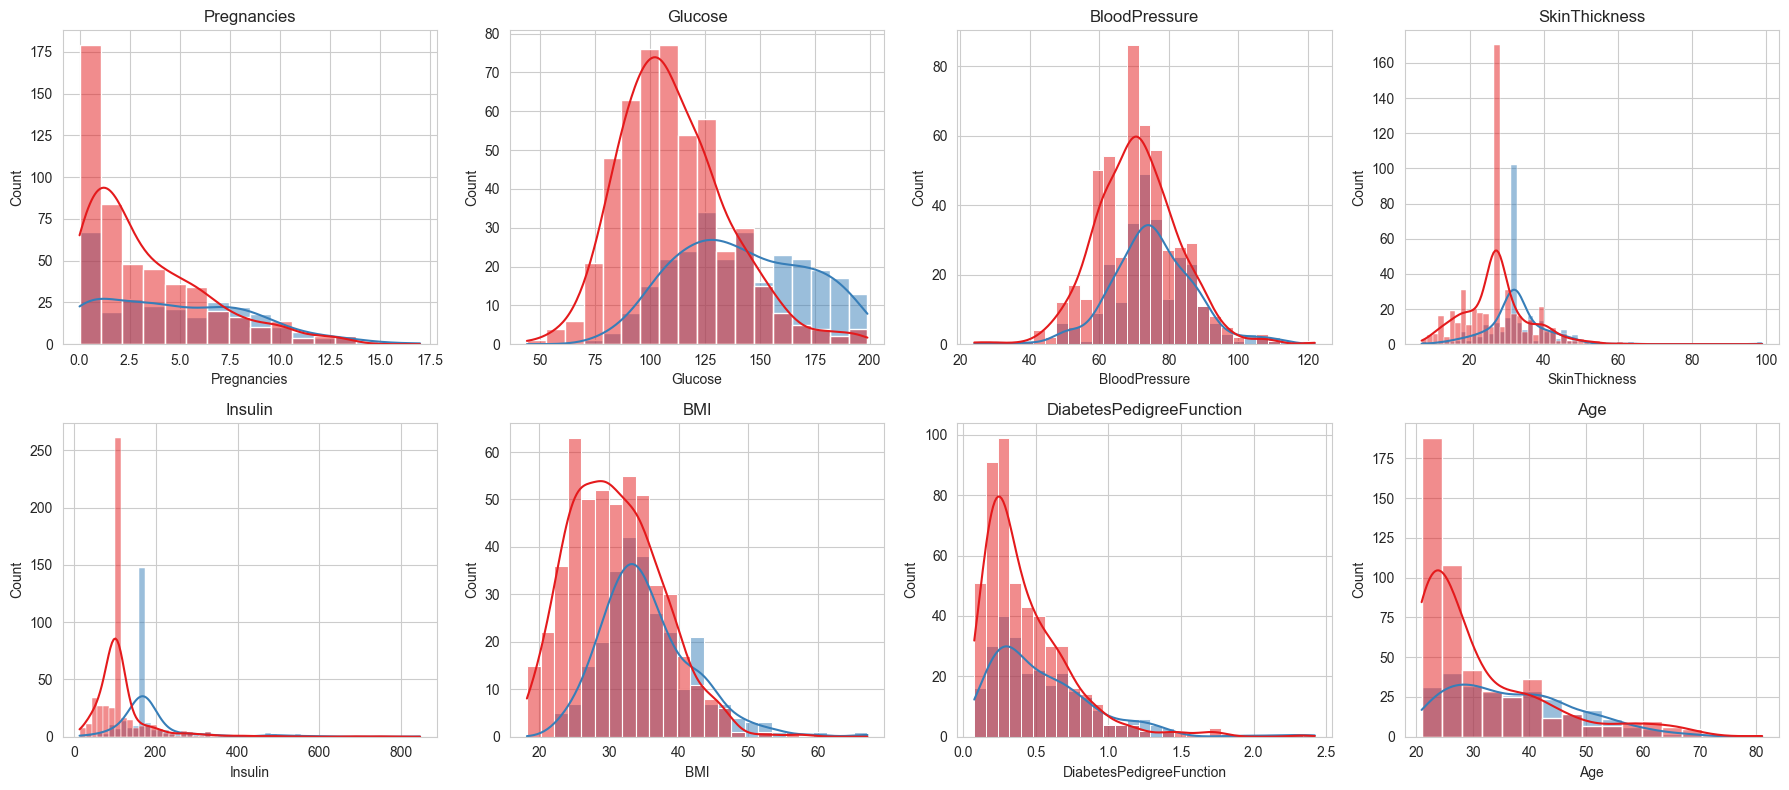

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, df_clean.columns[:-1]):
    sns.histplot(data=df_clean, x=col, hue="Outcome", kde=True, ax=ax, palette="Set1", legend=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()

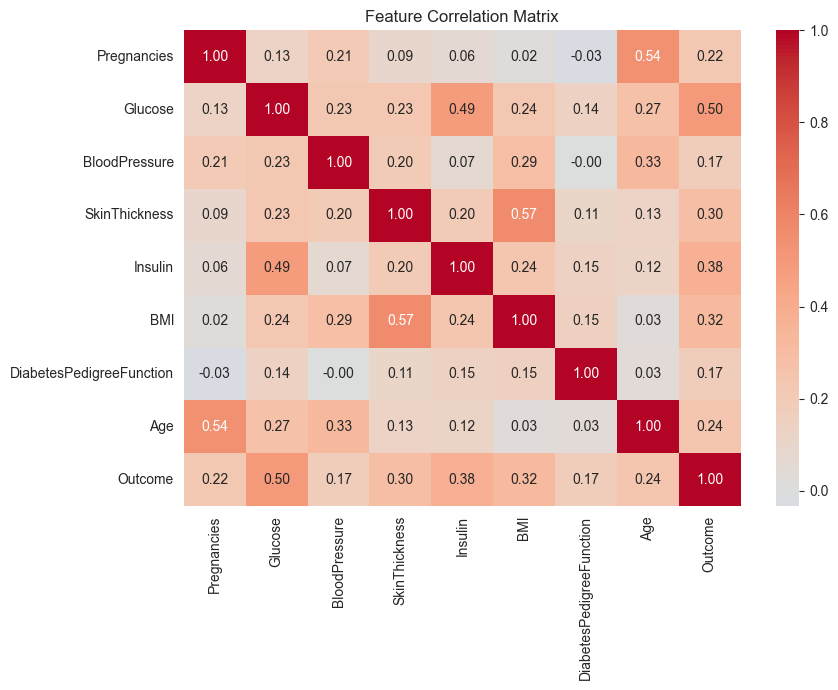

In [11]:
plt.figure(figsize=(9, 7))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

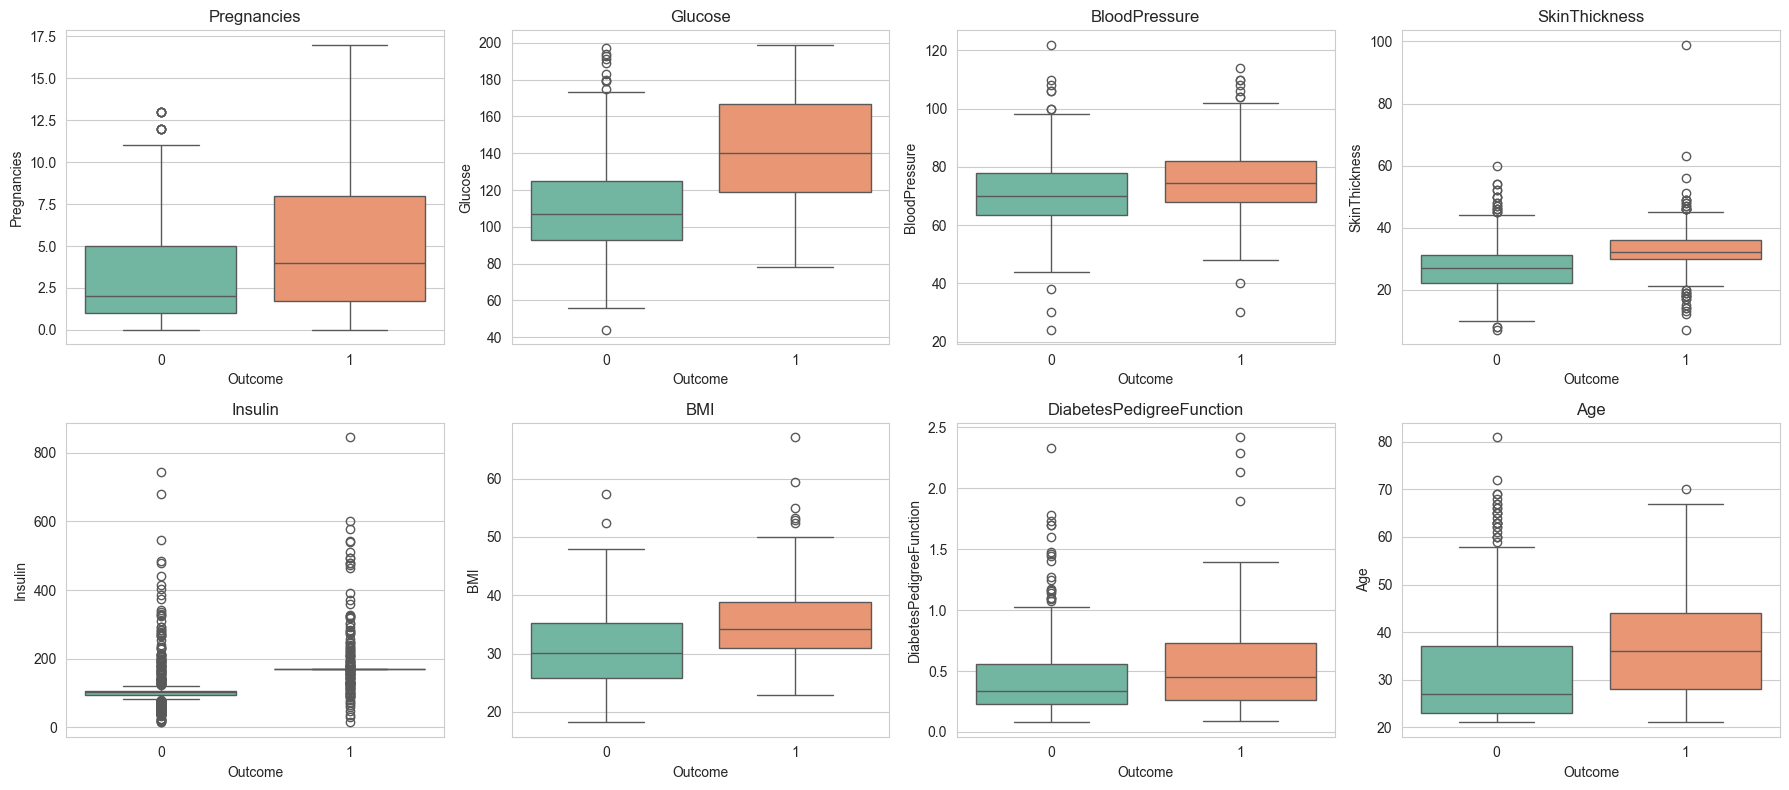

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, df_clean.columns[:-1]):
    sns.boxplot(data=df_clean, x="Outcome", y=col, hue="Outcome", ax=ax, palette="Set2", legend=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [13]:
glucose_pos = df_clean.loc[df_clean.Outcome == 1, "Glucose"]
glucose_neg = df_clean.loc[df_clean.Outcome == 0, "Glucose"]
t_stat, p_val = stats.ttest_ind(glucose_pos, glucose_neg, equal_var=False)
print(f"t-statistic = {t_stat:.3f}, p-value = {p_val:.6f}")
print("Reject H0 (p < 0.05):", p_val < 0.05)

t-statistic = 14.992, p-value = 0.000000
Reject H0 (p < 0.05): True


In [14]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"
df_clean["BMI_Category"] = df_clean["BMI"].apply(bmi_category)
contingency = pd.crosstab(df_clean["BMI_Category"], df_clean["Outcome"])
print(contingency)
chi2_stat, p_chi2, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi2 = {chi2_stat:.3f}, dof = {dof}, p-value = {p_chi2:.6f}")
print("Reject H0 (p < 0.05):", p_chi2 < 0.05)

Outcome         0    1
BMI_Category          
Normal         95    7
Obese         262  221
Overweight    139   40
Underweight     4    0

Chi2 = 74.908, dof = 3, p-value = 0.000000
Reject H0 (p < 0.05): True


In [15]:
groups = [g["Glucose"].values for _, g in df_clean.groupby("BMI_Category")]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"F-statistic = {f_stat:.3f}, p-value = {p_anova:.6f}")
print("Reject H0 (p < 0.05):", p_anova < 0.05)

F-statistic = 12.591, p-value = 0.000000
Reject H0 (p < 0.05): True


In [16]:
print(df_clean.groupby("BMI_Category")["Glucose"].agg(["mean", "std", "count"]))

                    mean        std  count
BMI_Category                              
Normal        109.029412  25.112994    102
Obese         126.320911  31.657702    483
Overweight    116.944134  27.159066    179
Underweight    95.250000   8.808140      4


In [17]:
df_fe = df_clean.copy()
df_fe["Age_Group"] = pd.cut(
    df_fe["Age"], bins=[20, 30, 40, 50, 60, 100],
    labels=["21-30", "31-40", "41-50", "51-60", "60+"]
)
df_fe["Glucose_Category"] = pd.cut(
    df_fe["Glucose"], bins=[0, 99, 125, 300],
    labels=["Normal", "Prediabetes", "Diabetes_Range"]
)
df_fe["Glucose_BMI_Interaction"] = df_fe["Glucose"] * df_fe["BMI"]
df_fe["Insulin_Glucose_Ratio"] = df_fe["Insulin"] / df_fe["Glucose"]
df_fe = pd.get_dummies(
    df_fe, columns=["BMI_Category", "Age_Group", "Glucose_Category"], drop_first=True
)
print("Engineered feature set shape:", df_fe.shape)
df_fe.head()

Engineered feature set shape: (768, 20)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_BMI_Interaction,Insulin_Glucose_Ratio,BMI_Category_Obese,BMI_Category_Overweight,BMI_Category_Underweight,Age_Group_31-40,Age_Group_41-50,Age_Group_51-60,Age_Group_60+,Glucose_Category_Prediabetes,Glucose_Category_Diabetes_Range
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1,4972.8,1.145270,True,False,False,False,True,False,False,False,True
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0,2261.0,1.205882,False,True,False,True,False,False,False,False,False
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1,4263.9,0.926230,False,False,False,True,False,False,False,False,True
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,2500.9,1.056180,False,True,False,False,False,False,False,False,False
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,5904.7,1.226277,True,False,False,True,False,False,False,False,True


In [18]:
X = df_fe.drop(columns=["Outcome"])
y = df_fe["Outcome"]
selector = SelectKBest(score_func=f_classif, k="all")
selector.fit(X, y)
f_scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
print("Top features by ANOVA F-score:")
print(f_scores.head(10))

Top features by ANOVA F-score:
Glucose_BMI_Interaction            288.730351
Glucose                            249.923949
Glucose_Category_Diabetes_Range    157.242537
Insulin                            126.971455
BMI                                 84.722280
BMI_Category_Obese                  73.890957
SkinThickness                       73.089964
Insulin_Glucose_Ratio               49.554490
Age                                 46.140611
Pregnancies                         39.670227
dtype: float64


In [19]:
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf.fit(X, y)
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top features by Random Forest importance:")
print(rf_importance.head(10))

Top features by Random Forest importance:
Insulin                     0.288249
Glucose_BMI_Interaction     0.111879
Insulin_Glucose_Ratio       0.105119
SkinThickness               0.104574
Glucose                     0.099067
Age                         0.060935
BMI                         0.053090
DiabetesPedigreeFunction    0.046472
Pregnancies                 0.033770
BloodPressure               0.032237
dtype: float64


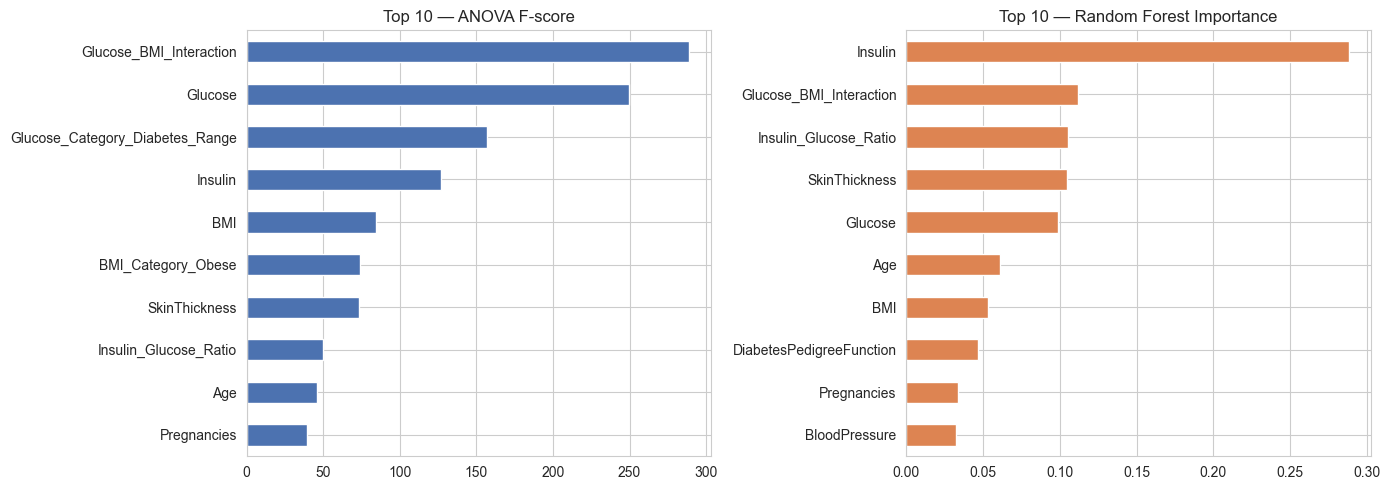

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
f_scores.head(10).plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].invert_yaxis()
axes[0].set_title("Top 10 — ANOVA F-score")
rf_importance.head(10).plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].invert_yaxis()
axes[1].set_title("Top 10 — Random Forest Importance")
plt.tight_layout()
plt.show()

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Train tensor shape:", X_train_scaled.shape)
print("Test tensor shape:", X_test_scaled.shape)
print("Train class balance:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test class balance:", y_test.value_counts(normalize=True).round(3).to_dict())

Train tensor shape: (614, 19)
Test tensor shape: (154, 19)
Train class balance: {0: 0.651, 1: 0.349}
Test class balance: {0: 0.649, 1: 0.351}


# Part B

In [23]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from nltk.stem import PorterStemmer
from wordcloud import WordCloud
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42
DATA_PATH = "mtsamples.csv"
df = pd.read_csv(DATA_PATH, index_col=0)
print("Shape:", df.shape)
df.head(3)

Shape: (4999, 5)


,description,medical_specialty,sample_name,transcription,keywords
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4999 entries, 0 to 4998
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   description        4999 non-null   object
 1   medical_specialty  4999 non-null   object
 2   sample_name        4999 non-null   object
 3   transcription      4966 non-null   object
 4   keywords           3931 non-null   object
dtypes: object(5)
memory usage: 234.3+ KB


In [25]:
print("Missing values:")
print(df.isna().sum())
print("\nDuplicate transcriptions:", df["transcription"].duplicated().sum())
print("Number of unique medical specialties:", df["medical_specialty"].nunique())

Missing values:
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64

Duplicate transcriptions: 2641
Number of unique medical specialties: 40


In [26]:
specialty_counts = df["medical_specialty"].str.strip().value_counts()
print(specialty_counts)

medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Urology                           158
Discharge Summary                 108
ENT - Otolaryngology               98
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    62
Psychiatry / Psychology            53
Office Notes                       51
Podiatry                           47
Dermatology                        29
Dentistry                          27
Cosmetic / Plastic Surgery      

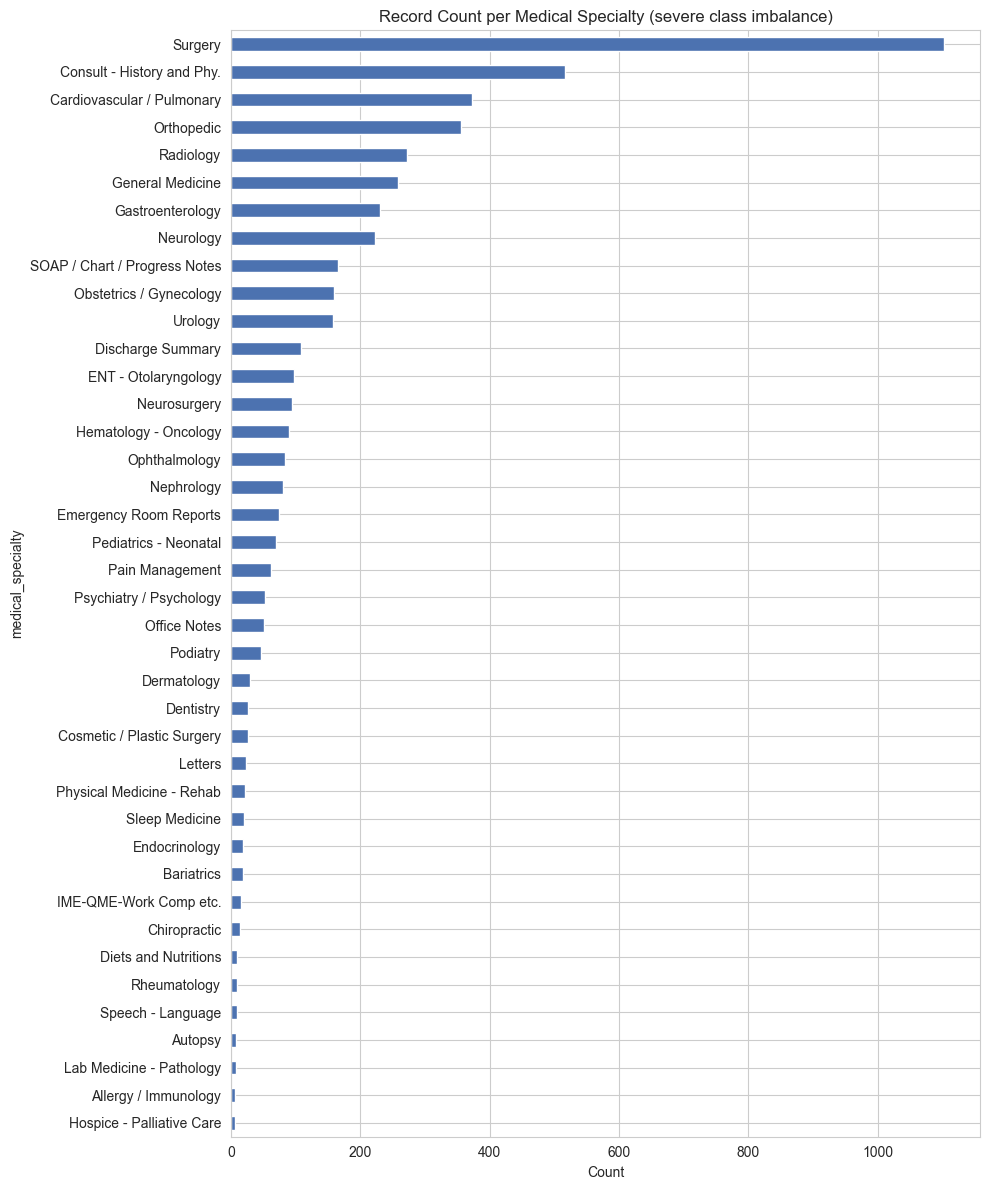

In [27]:
plt.figure(figsize=(10, 12))
specialty_counts.plot(kind="barh", color="#4C72B0")
plt.gca().invert_yaxis()
plt.title("Record Count per Medical Specialty (severe class imbalance)")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

In [28]:
print("Rows with missing transcription:", df["transcription"].isna().sum())
df_no_missing = df.dropna(subset=["transcription"]).copy()
n_unique_text = df_no_missing["transcription"].nunique()
print(f"Non-missing rows: {len(df_no_missing)}, unique transcription texts: {n_unique_text}")
df_clean = df_no_missing.drop_duplicates(subset=["transcription"]).reset_index(drop=True)
print("Shape after de-duplicating identical transcription text:", df_clean.shape)

Rows with missing transcription: 33
Non-missing rows: 4966, unique transcription texts: 2357
Shape after de-duplicating identical transcription text: (2357, 5)


In [29]:
PHI_PATTERNS = [
    (r"\bDr\.?\s+[A-Z][a-zA-Z'-]+\b", "[PHYSICIAN]"),
    (r"\b\d{1,2}/\d{1,2}/\d{2,4}\b", "[DATE]"),                 
    (r"\b\d{3}[-.]\d{3}[-.]\d{4}\b", "[PHONE]"),                
    (r"\b\d{3}-\d{2}-\d{4}\b", "[SSN]"),                        
    (r"\b[\w.+-]+@[\w-]+\.[\w.-]+\b", "[EMAIL]"),               
    (r"\bMRN[:\s#]*\d+\b", "[MRN]", ),                          
]
def scrub_phi(text):
    for pattern, repl in PHI_PATTERNS:
        text = re.sub(pattern, repl, text)
    return text
sample_before = df_clean.loc[0, "transcription"][:200]
df_clean["transcription_scrubbed"] = df_clean["transcription"].apply(scrub_phi)
sample_after = df_clean.loc[0, "transcription_scrubbed"][:200]
print("BEFORE:", sample_before)
print("\nAFTER: ", sample_after)

BEFORE: SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried 

AFTER:  SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried 


In [30]:
n_dates_found = df_clean["transcription"].str.count(r"\b\d{1,2}/\d{1,2}/\d{2,4}\b").sum()
n_physicians_found = df_clean["transcription"].str.count(r"\bDr\.?\s+[A-Z][a-zA-Z'-]+\b").sum()
print(f"Dates redacted: {n_dates_found}")
print(f"Physician-name mentions redacted: {n_physicians_found}")

Dates redacted: 1010
Physician-name mentions redacted: 315


In [31]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r",\s*,+", ", ", text)          
    text = re.sub(r"\s+", " ", text)                
    text = re.sub(r"\[.*?\]", " ", text)            
    text = re.sub(r"[^a-z0-9\s]", " ", text)        
    text = re.sub(r"\s+", " ", text).strip()
    return text
df_clean["transcription_processed"] = df_clean["transcription_scrubbed"].apply(clean_text)
df_clean[["transcription_scrubbed", "transcription_processed"]].head(2)

,transcription_scrubbed,transcription_processed
0,"SUBJECTIVE:, This 23-year-old white female pr...",subjective this 23 year old white female prese...
1,"PAST MEDICAL HISTORY:, He has difficulty climb...",past medical history he has difficulty climbin...


In [32]:
df_clean["word_count"] = df_clean["transcription_processed"].str.split().apply(len)
df_clean["char_count"] = df_clean["transcription_processed"].str.len()
print(df_clean[["word_count", "char_count"]].describe())

        word_count    char_count
count  2357.000000   2357.000000
mean    478.342809   2885.044124
std     325.212710   1921.230661
min       1.000000      9.000000
25%     248.000000   1499.000000
50%     412.000000   2489.000000
75%     633.000000   3805.000000
max    3110.000000  17940.000000


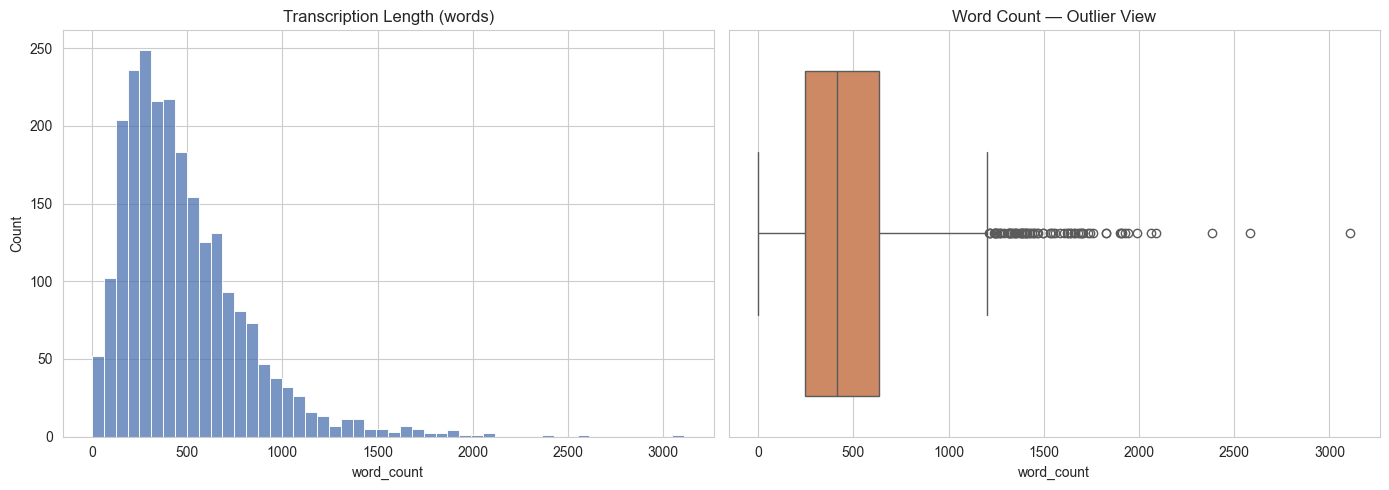

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_clean["word_count"], bins=50, ax=axes[0], color="#4C72B0")
axes[0].set_title("Transcription Length (words)")
sns.boxplot(x=df_clean["word_count"], ax=axes[1], color="#DD8452")
axes[1].set_title("Word Count — Outlier View")
plt.tight_layout()
plt.show()

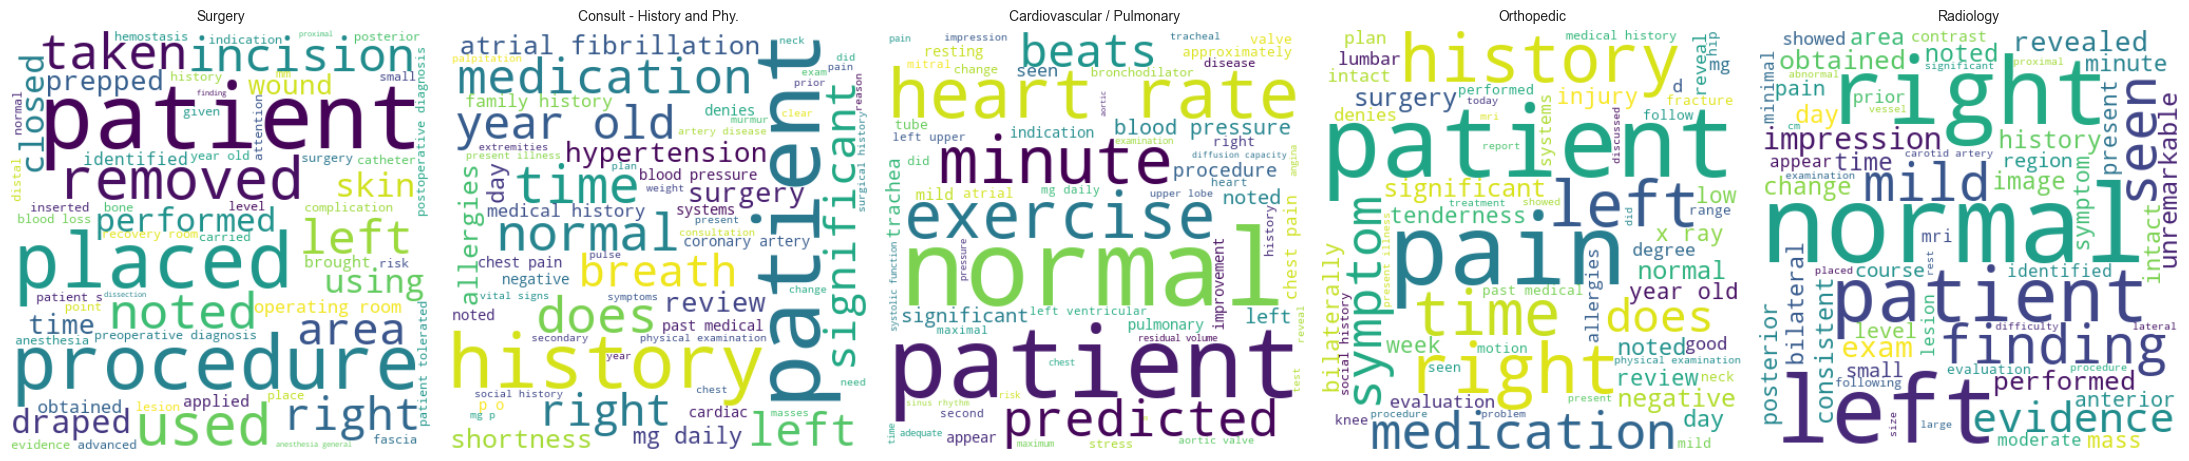

In [34]:
top5_specialties = specialty_counts.head(5).index.str.strip().tolist()
subset = df_clean[df_clean["medical_specialty"].str.strip().isin(top5_specialties)]
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, spec in zip(axes, top5_specialties):
    text_blob = " ".join(subset.loc[subset["medical_specialty"].str.strip() == spec, "transcription_processed"])
    wc = WordCloud(width=400, height=400, background_color="white",
                    stopwords=ENGLISH_STOP_WORDS, max_words=60).generate(text_blob)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(spec, fontsize=10)
plt.tight_layout()
plt.show()

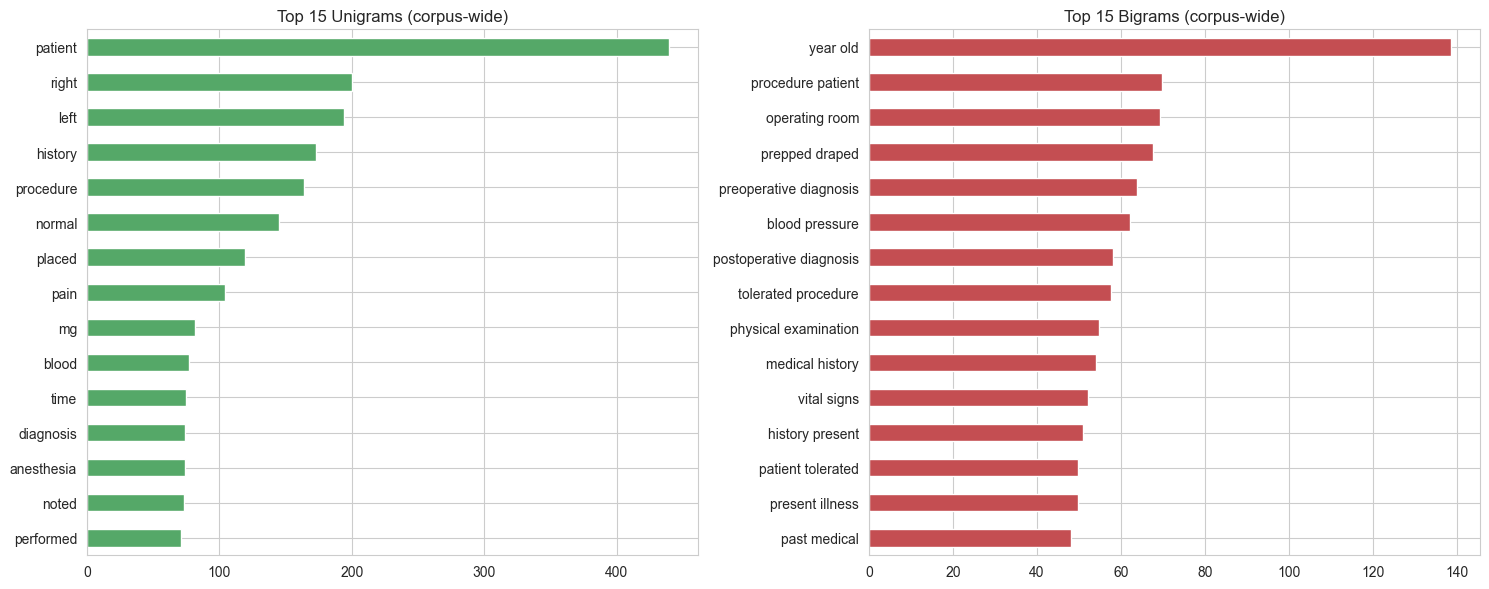

In [35]:
def top_ngrams(text_series, n=1, top_k=15, stop_words=ENGLISH_STOP_WORDS):
    vec = TfidfVectorizer(ngram_range=(n, n), stop_words=list(stop_words), max_features=5000, use_idf=False)
    X = vec.fit_transform(text_series)
    freqs = np.asarray(X.sum(axis=0)).ravel()
    vocab = vec.get_feature_names_out()
    top_idx = freqs.argsort()[::-1][:top_k]
    return pd.Series(freqs[top_idx], index=vocab[top_idx])
top_unigrams = top_ngrams(df_clean["transcription_processed"], n=1)
top_bigrams = top_ngrams(df_clean["transcription_processed"], n=2)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
top_unigrams.sort_values().plot(kind="barh", ax=axes[0], color="#55A868")
axes[0].set_title("Top 15 Unigrams (corpus-wide)")
top_bigrams.sort_values().plot(kind="barh", ax=axes[1], color="#C44E52")
axes[1].set_title("Top 15 Bigrams (corpus-wide)")
plt.tight_layout()
plt.show()

In [36]:
df_clean["keyword_count"] = df_clean["keywords"].fillna("").apply(
    lambda k: len([x for x in k.split(",") if x.strip()])
)
df_clean["has_numeric_value"] = df_clean["transcription_processed"].str.contains(r"\d").astype(int)
df_clean["sentence_count"] = df_clean["transcription_scrubbed"].str.count(r"[.!?]") + 1
df_clean[["word_count", "char_count", "keyword_count", "has_numeric_value", "sentence_count"]].describe()

,word_count,char_count,keyword_count,has_numeric_value,sentence_count
count,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000
mean,478.342809,2885.044124,10.405600,0.960119,44.981332
std,325.212710,1921.230661,7.339345,0.195722,29.010501
min,1.000000,9.000000,0.000000,0.000000,1.000000
25%,248.000000,1499.000000,6.000000,1.000000,23.000000
50%,412.000000,2489.000000,11.000000,1.000000,38.000000
75%,633.000000,3805.000000,15.000000,1.000000,60.000000
max,3110.000000,17940.000000,35.000000,1.000000,242.000000


In [37]:
stemmer = PorterStemmer()
stop_words = ENGLISH_STOP_WORDS
def tokenize_and_stem(text, min_len=2):
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) >= min_len and not t.isdigit()]
    return [stemmer.stem(t) for t in tokens]
df_clean["tokens"] = df_clean["transcription_processed"].apply(tokenize_and_stem)
df_clean["stemmed_text"] = df_clean["tokens"].apply(lambda toks: " ".join(toks))
df_clean[["transcription_processed", "stemmed_text"]].head(1)

,transcription_processed,stemmed_text
0,subjective this 23 year old white female prese...,subject year old white femal present complaint...


In [38]:
TOP_N = 10
top_n_specialties = specialty_counts.head(TOP_N).index.str.strip().tolist()
df_model = df_clean[df_clean["medical_specialty"].str.strip().isin(top_n_specialties)].copy()
df_model["medical_specialty"] = df_model["medical_specialty"].str.strip()
print(f"Retained {len(df_model)} / {len(df_clean)} records across top-{TOP_N} specialties")
print(df_model["medical_specialty"].value_counts())

Retained 1786 / 2357 records across top-10 specialties
medical_specialty
Surgery                          976
Radiology                        248
General Medicine                 157
SOAP / Chart / Progress Notes    144
Neurology                         67
Orthopedic                        56
Consult - History and Phy.        55
Gastroenterology                  31
Cardiovascular / Pulmonary        26
Obstetrics / Gynecology           26
Name: count, dtype: int64


In [39]:
le = LabelEncoder()
y = le.fit_transform(df_model["medical_specialty"])
tfidf = TfidfVectorizer(max_features=3000, min_df=3, max_df=0.9, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df_model["stemmed_text"])
print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (1786, 3000)


In [40]:
chi2_scores, p_values = chi2(X_tfidf, y)
feature_names = np.array(tfidf.get_feature_names_out())
top_chi2_idx = chi2_scores.argsort()[::-1][:20]
chi2_table = pd.DataFrame({
    "term": feature_names[top_chi2_idx],
    "chi2_score": chi2_scores[top_chi2_idx],
    "p_value": p_values[top_chi2_idx]
})
print(chi2_table)

          term  chi2_score       p_value
0      predict  165.892672  4.420778e-31
1        capac  119.864464  1.424305e-21
2          pap   98.939809  2.577645e-17
3      histori   83.603328  3.099534e-14
4           mg   54.671543  1.406690e-08
5        daili   52.999458  2.923594e-08
6         imag   52.826343  3.153068e-08
7        smear   51.584360  5.416535e-08
8      exercis   49.509865  1.331694e-07
9        medic   49.423992  1.382056e-07
10     subject   48.799373  1.809917e-07
11  heart rate   47.637007  2.985559e-07
12        pain   46.782676  4.307908e-07
13        beat   43.501142  1.743794e-06
14        past   43.223239  1.961448e-06
15    mg daili   43.007204  2.149054e-06
16        deni   42.709338  2.437182e-06
17    discharg   41.189632  4.619671e-06
18  beat minut   40.363496  6.528565e-06
19     allergi   39.010138  1.147218e-05


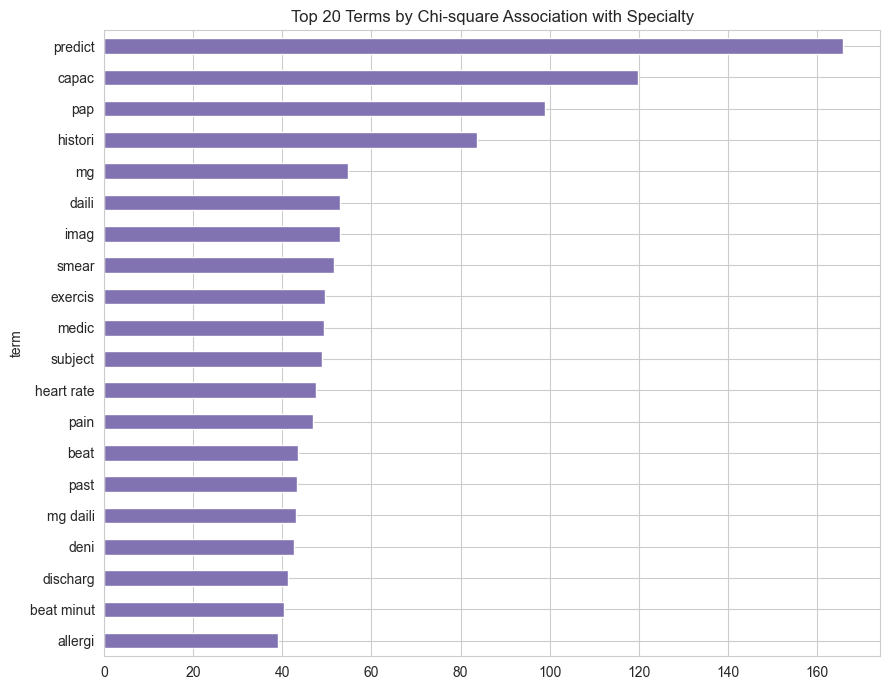

In [41]:
plt.figure(figsize=(9, 7))
chi2_table.set_index("term")["chi2_score"].sort_values().plot(kind="barh", color="#8172B2")
plt.title("Top 20 Terms by Chi-square Association with Specialty")
plt.tight_layout()
plt.show()

In [42]:
K = 800
selector = SelectKBest(chi2, k=K)
X_selected = selector.fit_transform(X_tfidf, y)
print("Reduced TF-IDF shape after Chi-square selection:", X_selected.shape)

Reduced TF-IDF shape after Chi-square selection: (1786, 800)


In [43]:
SYNONYM_MAP = {
    "patient": ["patient", "individual", "case"],
    "pain": ["pain", "discomfort", "ache"],
    "history": ["history", "background"],
    "normal": ["normal", "unremarkable"],
    "denies": ["denies", "reports no"],
    "mild": ["mild", "slight"],
    "severe": ["severe", "significant"],
    "surgery": ["surgery", "operation", "procedure"],
}
rng = np.random.default_rng(RANDOM_STATE)
def synonym_augment(text, p=0.3):
    words = text.split()
    out = []
    for w in words:
        if w in SYNONYM_MAP and rng.random() < p:
            out.append(rng.choice(SYNONYM_MAP[w]))
        else:
            out.append(w)
    return " ".join(out)
class_counts = df_model["medical_specialty"].value_counts()
minority_classes = class_counts[class_counts < class_counts.median()].index.tolist()
print("Augmenting minority classes:", minority_classes)
aug_rows = []
for _, row in df_model[df_model["medical_specialty"].isin(minority_classes)].iterrows():
    aug_rows.append({
        "medical_specialty": row["medical_specialty"],
        "stemmed_text": synonym_augment(row["stemmed_text"]),
        "source": "augmented"
    })
df_aug = pd.DataFrame(aug_rows)
print(f"Generated {len(df_aug)} augmented samples for minority classes")
df_model_aug = pd.concat([
    df_model[["medical_specialty", "stemmed_text"]].assign(source="original"),
    df_aug
], ignore_index=True)
print(df_model_aug["medical_specialty"].value_counts())

Augmenting minority classes: ['Orthopedic', 'Consult - History and Phy.', 'Gastroenterology', 'Cardiovascular / Pulmonary', 'Obstetrics / Gynecology']
Generated 194 augmented samples for minority classes
medical_specialty
Surgery                          976
Radiology                        248
General Medicine                 157
SOAP / Chart / Progress Notes    144
Orthopedic                       112
Consult - History and Phy.       110
Neurology                         67
Gastroenterology                  62
Cardiovascular / Pulmonary        52
Obstetrics / Gynecology           52
Name: count, dtype: int64


In [44]:
y_aug = le.transform(df_model_aug["medical_specialty"])
X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    df_model_aug["stemmed_text"], y_aug, test_size=0.2,
    random_state=RANDOM_STATE, stratify=y_aug
)
tfidf_final = TfidfVectorizer(max_features=3000, min_df=3, max_df=0.9, ngram_range=(1, 2))
X_train_tfidf = tfidf_final.fit_transform(X_train_txt)
X_test_tfidf = tfidf_final.transform(X_test_txt)
print("TF-IDF train/test shapes:", X_train_tfidf.shape, X_test_tfidf.shape)

TF-IDF train/test shapes: (1584, 3000) (396, 3000)


In [45]:
VOCAB_SIZE = 5000
MAX_LEN = 200
all_tokens = " ".join(X_train_txt).split()
vocab_freq = Counter(all_tokens)
vocab = ["<PAD>", "<UNK>"] + [w for w, _ in vocab_freq.most_common(VOCAB_SIZE - 2)]
word2idx = {w: i for i, w in enumerate(vocab)}
def text_to_sequence(text, max_len=MAX_LEN):
    ids = [word2idx.get(w, word2idx["<UNK>"]) for w in text.split()]
    if len(ids) < max_len:
        ids = ids + [word2idx["<PAD>"]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]
    return ids
X_train_seq = np.array([text_to_sequence(t) for t in X_train_txt])
X_test_seq = np.array([text_to_sequence(t) for t in X_test_txt])
print("Token sequence train/test shapes:", X_train_seq.shape, X_test_seq.shape)
print("Vocabulary size:", len(vocab))

Token sequence train/test shapes: (1584, 200) (396, 200)
Vocabulary size: 5000


# Part C

In [46]:
import os
import glob
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFilter
from skimage.feature import graycomatrix, graycoprops
from skimage.filters import sobel, gaussian
from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

IMG_SIZE = 150
SPLITS = ["train", "val", "test"]
CLASSES = ["NORMAL", "PNEUMONIA"]
IMAGE_EXTENSIONS = ("*.jpeg", "*.jpg", "*.png", "*.bmp", "*.tif", "*.tiff")
DATA_DIR = os.path.join(os.getcwd(), "chest_xray")

def has_expected_structure(root):
    return all(
        os.path.isdir(os.path.join(root, split, cls))
        for split in SPLITS
        for cls in CLASSES
    )

if not has_expected_structure(DATA_DIR):
    candidates = [
        os.path.join(os.getcwd(), "chest_xray"),
        os.path.join(os.getcwd(), "data", "chest_xray"),
    ]
    current = os.getcwd()
    for _ in range(3):
        candidates.append(os.path.join(current, "chest_xray"))
        current = os.path.dirname(current)

    for candidate in candidates:
        if has_expected_structure(candidate):
            DATA_DIR = candidate
            break

if not has_expected_structure(DATA_DIR):
    raise FileNotFoundError(
        "Could not find the real chest_xray dataset. "    )

print("Using dataset:", os.path.abspath(DATA_DIR))

def list_files(split, cls):
    files = []
    folder = os.path.join(DATA_DIR, split, cls)
    for pattern in IMAGE_EXTENSIONS:
        files.extend(glob.glob(os.path.join(folder, pattern)))
        files.extend(glob.glob(os.path.join(folder, pattern.upper())))
    return sorted(set(files))

file_index = []
for split in SPLITS:
    for cls in CLASSES:
        for f in list_files(split, cls):
            file_index.append({"split": split, "class": cls, "path": f})

file_df = pd.DataFrame(file_index)

if file_df.empty:
    raise RuntimeError("No image files were found. Check DATA_DIR and the folder structure.")

print("Total image files found:", len(file_df))
print("\nImages by split and class:")
print(file_df.groupby(["split", "class"]).size().unstack(fill_value=0))

os.makedirs("outputs_image", exist_ok=True)


Using dataset: c:\Users\anany\OneDrive\Desktop\New folder\LAB3\chest_xray
Total image files found: 5856

Images by split and class:
class  NORMAL  PNEUMONIA
split                   
test      234        390
train    1341       3875
val         8          8


Sample image mode: L size: (2090, 1858)


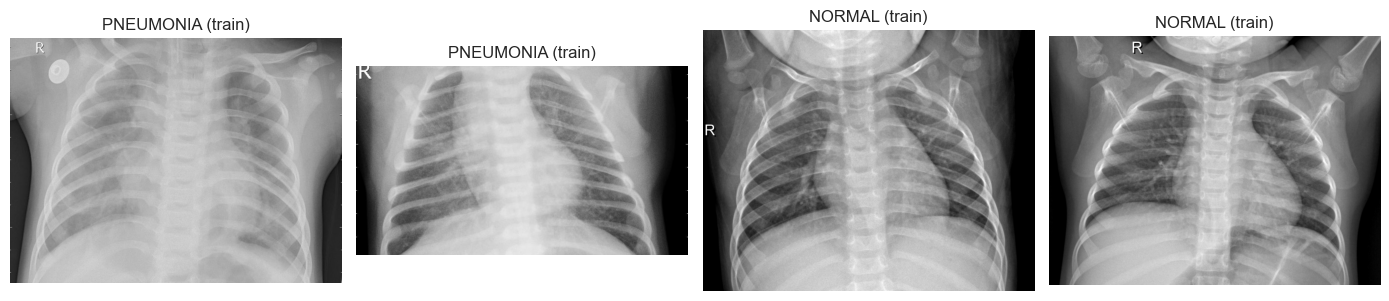

In [47]:
sample_img = Image.open(file_df.loc[0, "path"])
print("Sample image mode:", sample_img.mode, "size:", sample_img.size)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (_, row) in zip(axes, file_df.sample(4, random_state=RANDOM_STATE).iterrows()):
    img = Image.open(row["path"])
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{row['class']} ({row['split']})")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [48]:
val_counts = file_df[file_df.split == "val"].groupby("class").size()
print("Validation split sizes:\n", val_counts)
print(f"\nTotal validation images: {val_counts.sum()}")

Validation split sizes:
 class
NORMAL       8
PNEUMONIA    8
dtype: int64

Total validation images: 16


In [49]:
def is_readable(path):
    try:
        with Image.open(path) as img:
            img.load()
        return True
    except Exception:
        return False

file_df["readable"] = file_df["path"].apply(is_readable)
corrupt_files = file_df[~file_df["readable"]]
print(f"Corrupt/unreadable files found: {len(corrupt_files)}")
print(corrupt_files[["split", "class", "path"]])

file_df = file_df[file_df["readable"]].reset_index(drop=True)
print("\nRemaining files after dropping corrupt ones:", len(file_df))

Corrupt/unreadable files found: 0
Empty DataFrame
Columns: [split, class, path]
Index: []

Remaining files after dropping corrupt ones: 5856


In [50]:
def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

file_df["hash"] = file_df["path"].apply(file_hash)
dup_mask = file_df.duplicated(subset="hash", keep="first")
n_dups = dup_mask.sum()
print(f"Exact duplicate images found: {n_dups}")
print(file_df[dup_mask][["split", "class", "path"]])

dup_groups = file_df[file_df.duplicated(subset="hash", keep=False)].groupby("hash")["split"].nunique()
print("\nDuplicate groups spanning >1 split (leakage risk):", (dup_groups > 1).sum())

file_df = file_df[~dup_mask].reset_index(drop=True)
print("Remaining files after de-duplication:", len(file_df))

Exact duplicate images found: 32
      split      class                                               path
754   train     NORMAL  c:\Users\anany\OneDrive\Desktop\New folder\LAB...
1634  train  PNEUMONIA  c:\Users\anany\OneDrive\Desktop\New folder\LAB...
1823  train  PNEUMONIA  c:\Users\anany\OneDrive\Desktop\New folder\LAB...
1847  train  PNEUMONIA  c:\Users\anany\OneDrive\Desktop\New folder\LAB...
1962  train  PNEUMONIA  c:\Users\anany\OneDrive\Desktop\New folder\LAB...
2044  train  PNEUMONIA  c:\Users\anany\OneDrive\Desktop\New folder\LAB...
2069  train  PNEUMONIA  c:\Users\anany\OneDrive\Desktop\New folder\LAB...
2119  train  PNEUMONIA  c:\Users\anany\OneDrive\Desktop\New folder\LAB...
2120  train  PNEUMONIA  c:\Users\anany\OneDrive\Desktop\New folder\LAB...
2250  train  PNEUMONIA  c:\Users\anany\OneDrive\Desktop\New folder\LAB...
2368  train  PNEUMONIA  c:\Users\anany\OneDrive\Desktop\New folder\LAB...
2370  train  PNEUMONIA  c:\Users\anany\OneDrive\Desktop\New folder\LAB...
2372 

In [51]:
def load_and_preprocess(path, size=IMG_SIZE):
    img = Image.open(path).convert("L")          
    img = img.resize((size, size))
    arr = np.asarray(img, dtype=np.float32) / 255.0  
    return arr

file_df["array"] = file_df["path"].apply(load_and_preprocess)
X_all = np.stack(file_df["array"].values)
print("Full image tensor shape:", X_all.shape)
print("Pixel value range after normalization:", X_all.min(), "-", X_all.max())

Full image tensor shape: (5824, 150, 150)
Pixel value range after normalization: 0.0 - 1.0


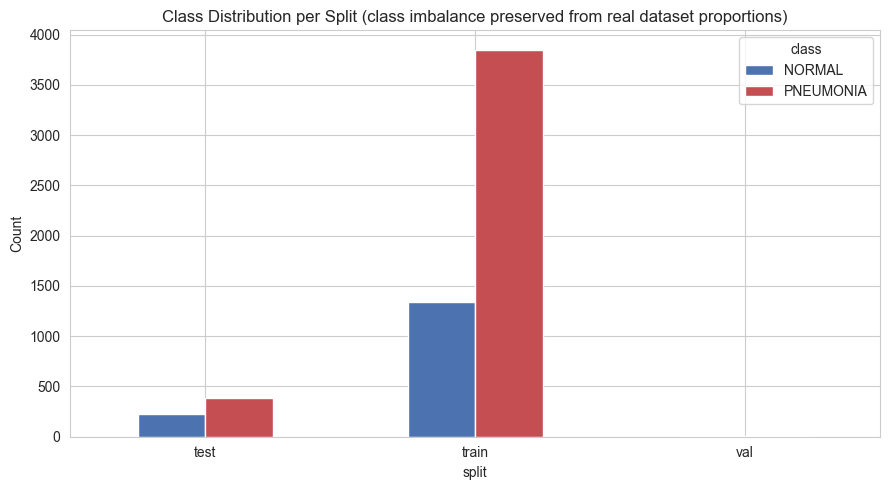

In [52]:
class_dist = file_df.groupby(["split", "class"]).size().unstack()
class_dist.plot(kind="bar", stacked=False, figsize=(9, 5), color=["#4C72B0", "#C44E52"])
plt.title("Class Distribution per Split (class imbalance preserved from real dataset proportions)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

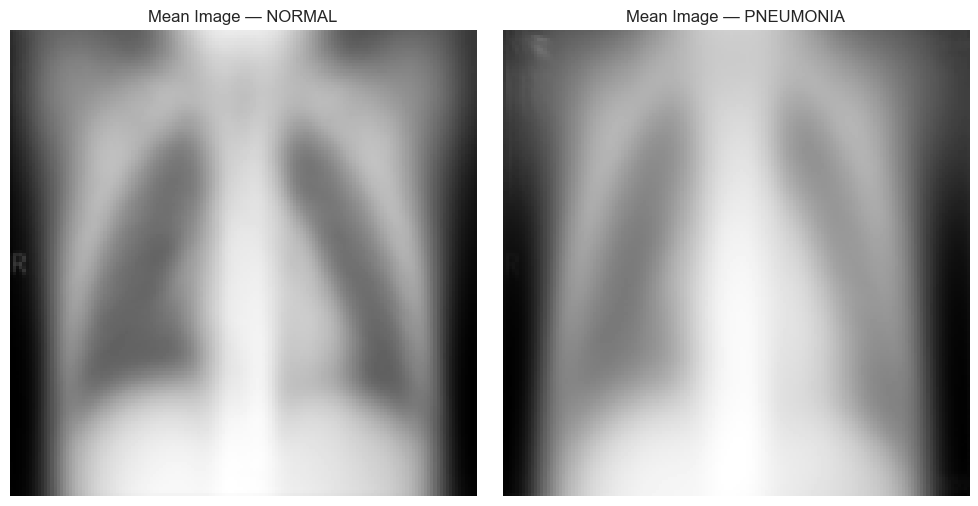

In [53]:
mean_normal = X_all[file_df["class"] == "NORMAL"].mean(axis=0)
mean_pneumonia = X_all[file_df["class"] == "PNEUMONIA"].mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(mean_normal, cmap="gray")
axes[0].set_title("Mean Image — NORMAL")
axes[0].axis("off")
axes[1].imshow(mean_pneumonia, cmap="gray")
axes[1].set_title("Mean Image — PNEUMONIA")
axes[1].axis("off")
plt.tight_layout()
plt.show()

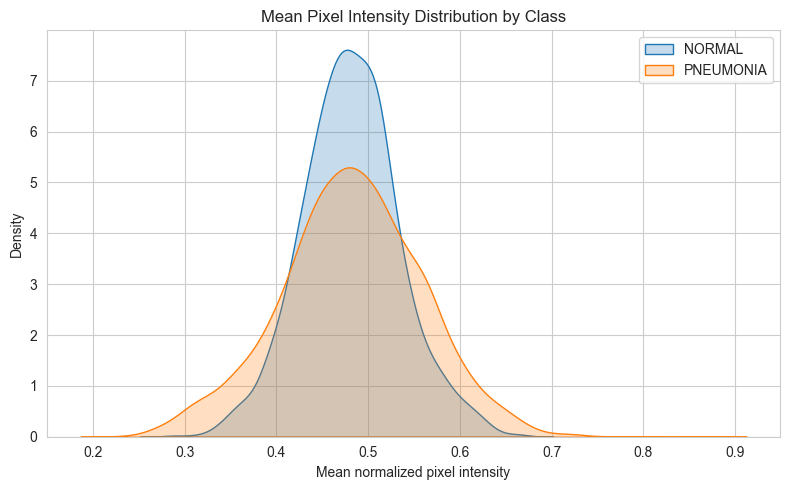

In [54]:
plt.figure(figsize=(8, 5))
sns.kdeplot(X_all[file_df["class"] == "NORMAL"].mean(axis=(1, 2)), label="NORMAL", fill=True)
sns.kdeplot(X_all[file_df["class"] == "PNEUMONIA"].mean(axis=(1, 2)), label="PNEUMONIA", fill=True)
plt.title("Mean Pixel Intensity Distribution by Class")
plt.xlabel("Mean normalized pixel intensity")
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
train_df = file_df[file_df.split == "train"].reset_index(drop=True)
test_df = file_df[file_df.split == "test"].reset_index(drop=True)

train_idx, val_idx = train_test_split(
    train_df.index, test_size=0.15, random_state=RANDOM_STATE, stratify=train_df["class"]
)
new_train_df = train_df.loc[train_idx].reset_index(drop=True)
new_val_df = train_df.loc[val_idx].reset_index(drop=True)

print("New train size:", len(new_train_df), dict(new_train_df["class"].value_counts()))
print("New val size:", len(new_val_df), dict(new_val_df["class"].value_counts()))
print("Test size (unchanged):", len(test_df), dict(test_df["class"].value_counts()))

New train size: 4411 {'PNEUMONIA': np.int64(3272), 'NORMAL': np.int64(1139)}
New val size: 779 {'PNEUMONIA': np.int64(578), 'NORMAL': np.int64(201)}
Test size (unchanged): 618 {'PNEUMONIA': np.int64(387), 'NORMAL': np.int64(231)}


In [56]:
def extract_features(img_float):
    img_uint8 = (img_float * 255).astype(np.uint8)
    glcm = graycomatrix(img_uint8, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, "contrast")[0, 0]
    homogeneity = graycoprops(glcm, "homogeneity")[0, 0]
    energy = graycoprops(glcm, "energy")[0, 0]
    correlation = graycoprops(glcm, "correlation")[0, 0]

    edges = sobel(img_float)
    edge_density = (edges > edges.mean() + edges.std()).mean()

    return {
        "mean_intensity": img_float.mean(),
        "std_intensity": img_float.std(),
        "glcm_contrast": contrast,
        "glcm_homogeneity": homogeneity,
        "glcm_energy": energy,
        "glcm_correlation": correlation,
        "edge_density": edge_density,
    }

feat_records = []
for i, row in file_df.iterrows():
    feats = extract_features(row["array"])
    feats["class"] = row["class"]
    feats["split"] = row["split"]
    feat_records.append(feats)
feat_df = pd.DataFrame(feat_records)
print(feat_df.groupby("class").mean(numeric_only=True))

           mean_intensity  std_intensity  glcm_contrast  glcm_homogeneity  \
class                                                                       
NORMAL           0.480887       0.238630     152.472650          0.229705   
PNEUMONIA        0.481676       0.215819     110.963895          0.268605   

           glcm_energy  glcm_correlation  edge_density  
class                                                   
NORMAL        0.067704          0.978726      0.127502  
PNEUMONIA     0.049308          0.981279      0.119300  


ANOVA F-scores (texture feature vs class):
glcm_homogeneity    1223.351467
glcm_contrast       1081.022184
edge_density         537.797295
std_intensity        480.666395
glcm_energy          269.056528
glcm_correlation     182.550688
mean_intensity         0.137844
dtype: float64


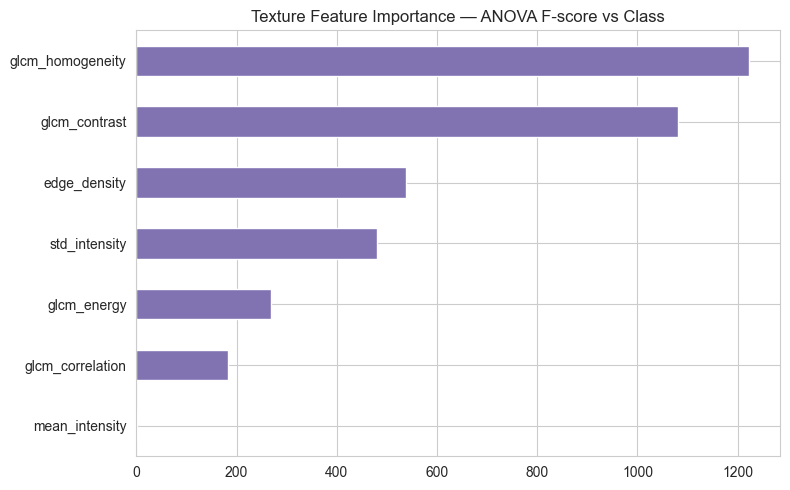

In [57]:
feature_cols = ["mean_intensity", "std_intensity", "glcm_contrast",
                 "glcm_homogeneity", "glcm_energy", "glcm_correlation", "edge_density"]

f_scores, p_vals = f_classif(feat_df[feature_cols], feat_df["class"])
f_score_series = pd.Series(f_scores, index=feature_cols).sort_values(ascending=False)
print("ANOVA F-scores (texture feature vs class):")
print(f_score_series)

plt.figure(figsize=(8, 5))
f_score_series.plot(kind="barh", color="#8172B2")
plt.gca().invert_yaxis()
plt.title("Texture Feature Importance — ANOVA F-score vs Class")
plt.tight_layout()
plt.show()

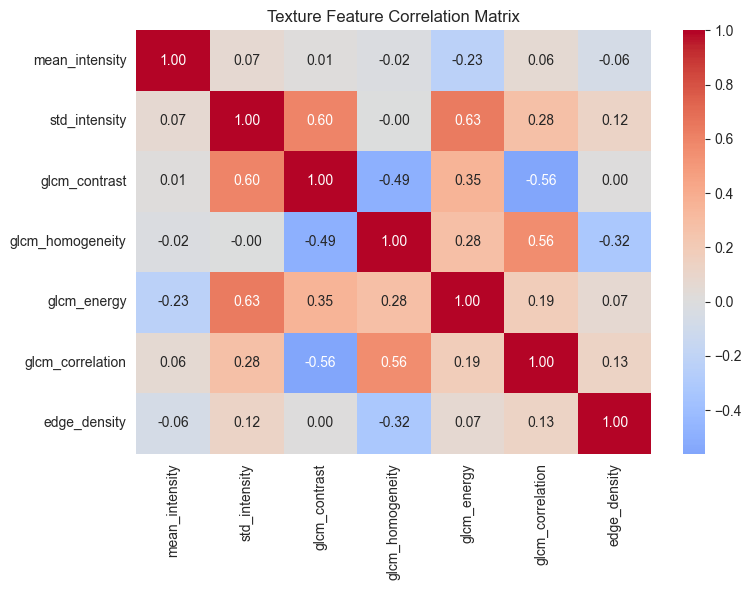

In [58]:
plt.figure(figsize=(8, 6))
sns.heatmap(feat_df[feature_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Texture Feature Correlation Matrix")
plt.tight_layout()
plt.show()

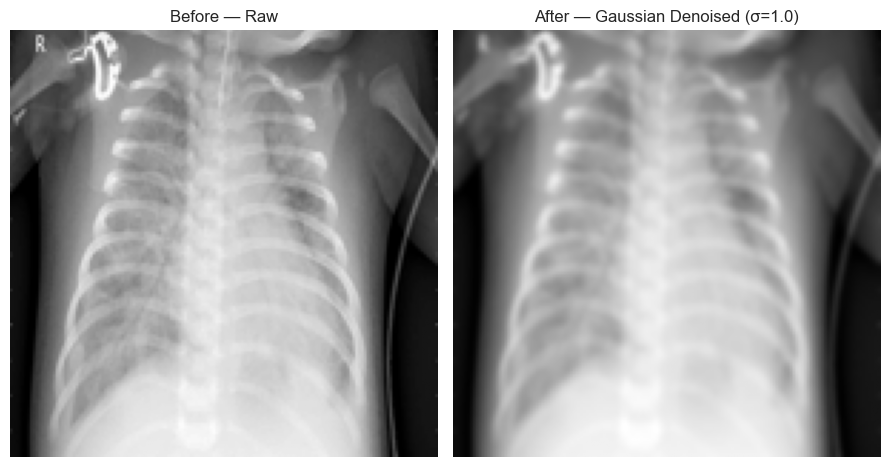

In [59]:
sample_pneumonia = file_df[file_df["class"] == "PNEUMONIA"].iloc[0]["array"]
denoised = gaussian(sample_pneumonia, sigma=1.0)

fig, axes = plt.subplots(1, 2, figsize=(9, 5))
axes[0].imshow(sample_pneumonia, cmap="gray")
axes[0].set_title("Before — Raw")
axes[0].axis("off")
axes[1].imshow(denoised, cmap="gray")
axes[1].set_title("After — Gaussian Denoised (σ=1.0)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [60]:
def augment_image(img_float):
    img = Image.fromarray((img_float * 255).astype(np.uint8))
    if rng.random() < 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
    angle = rng.uniform(-15, 15)
    img = img.rotate(angle, fillcolor=0)
    brightness_factor = rng.uniform(0.85, 1.15)
    arr = np.clip(np.asarray(img, dtype=np.float32) * brightness_factor, 0, 255)
    if rng.random() < 0.5:
        arr = np.asarray(Image.fromarray(arr.astype(np.uint8)).filter(ImageFilter.GaussianBlur(0.5)), dtype=np.float32)
    return arr / 255.0

train_normal = new_train_df[new_train_df["class"] == "NORMAL"]
train_pneumonia = new_train_df[new_train_df["class"] == "PNEUMONIA"]
target_normal_count = len(train_pneumonia)  

n_needed = max(0, target_normal_count - len(train_normal))
augmented_arrays, augmented_labels = [], []
for _ in range(n_needed):
    src_row = train_normal.sample(1, random_state=None).iloc[0]
    aug_img = augment_image(src_row["array"])
    augmented_arrays.append(aug_img)
    augmented_labels.append("NORMAL")

print(f"Generated {len(augmented_arrays)} augmented NORMAL images "
      f"(train NORMAL {len(train_normal)} -> {len(train_normal) + len(augmented_arrays)}, "
      f"train PNEUMONIA {len(train_pneumonia)})")

Generated 2133 augmented NORMAL images (train NORMAL 1139 -> 3272, train PNEUMONIA 3272)


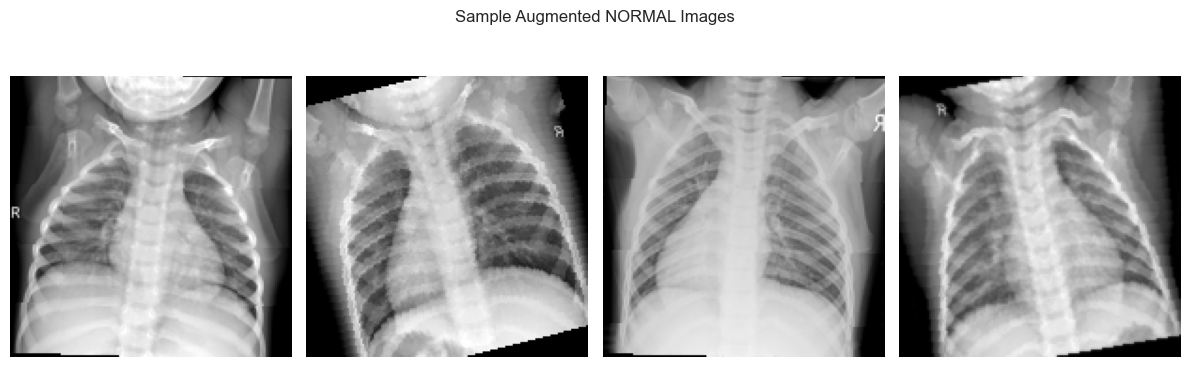

In [61]:
if augmented_arrays:
    fig, axes = plt.subplots(1, min(4, len(augmented_arrays)), figsize=(12, 4))
    axes = np.atleast_1d(axes)
    for ax, arr in zip(axes, augmented_arrays[:4]):
        ax.imshow(arr, cmap="gray")
        ax.axis("off")
    plt.suptitle("Sample Augmented NORMAL Images")
    plt.tight_layout()
    plt.show()
else:
    print("No augmentation was needed because the training classes are already balanced.")


In [62]:
X_train_final = np.stack(list(new_train_df["array"]) + augmented_arrays)
y_train_final = np.array(list(new_train_df["class"]) + augmented_labels)

X_val_final = np.stack(new_val_df["array"].values)
y_val_final = new_val_df["class"].values

X_test_final = np.stack(test_df["array"].values)
y_test_final = test_df["class"].values

le = LabelEncoder()
le.fit(["NORMAL", "PNEUMONIA"])
y_train_enc = le.transform(y_train_final)
y_val_enc = le.transform(y_val_final)
y_test_enc = le.transform(y_test_final)

X_train_tensor = X_train_final.reshape(-1, IMG_SIZE, IMG_SIZE, 1).astype(np.float32)
X_val_tensor = X_val_final.reshape(-1, IMG_SIZE, IMG_SIZE, 1).astype(np.float32)
X_test_tensor = X_test_final.reshape(-1, IMG_SIZE, IMG_SIZE, 1).astype(np.float32)

print("Train tensor:", X_train_tensor.shape, "class balance:", pd.Series(y_train_final).value_counts(normalize=True).round(3).to_dict())
print("Val tensor:  ", X_val_tensor.shape, "class balance:", pd.Series(y_val_final).value_counts(normalize=True).round(3).to_dict())
print("Test tensor: ", X_test_tensor.shape, "class balance:", pd.Series(y_test_final).value_counts(normalize=True).round(3).to_dict())

Train tensor: (6544, 150, 150, 1) class balance: {'PNEUMONIA': 0.5, 'NORMAL': 0.5}
Val tensor:   (779, 150, 150, 1) class balance: {'PNEUMONIA': 0.742, 'NORMAL': 0.258}
Test tensor:  (618, 150, 150, 1) class balance: {'PNEUMONIA': 0.626, 'NORMAL': 0.374}


# Part D

In [63]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
from scipy.signal import butter, filtfilt, iirnotch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
DATA_DIR = "mit-bih-arrhythmia-database-1.0.0"
record_ids = sorted(set(
    f.split("/")[-1].replace(".hea", "") for f in glob.glob(f"{DATA_DIR}/*.hea")
))
print(f"Records available: {len(record_ids)}")
print(record_ids)

Records available: 48
['mit-bih-arrhythmia-database-1.0.0\\100', 'mit-bih-arrhythmia-database-1.0.0\\101', 'mit-bih-arrhythmia-database-1.0.0\\102', 'mit-bih-arrhythmia-database-1.0.0\\103', 'mit-bih-arrhythmia-database-1.0.0\\104', 'mit-bih-arrhythmia-database-1.0.0\\105', 'mit-bih-arrhythmia-database-1.0.0\\106', 'mit-bih-arrhythmia-database-1.0.0\\107', 'mit-bih-arrhythmia-database-1.0.0\\108', 'mit-bih-arrhythmia-database-1.0.0\\109', 'mit-bih-arrhythmia-database-1.0.0\\111', 'mit-bih-arrhythmia-database-1.0.0\\112', 'mit-bih-arrhythmia-database-1.0.0\\113', 'mit-bih-arrhythmia-database-1.0.0\\114', 'mit-bih-arrhythmia-database-1.0.0\\115', 'mit-bih-arrhythmia-database-1.0.0\\116', 'mit-bih-arrhythmia-database-1.0.0\\117', 'mit-bih-arrhythmia-database-1.0.0\\118', 'mit-bih-arrhythmia-database-1.0.0\\119', 'mit-bih-arrhythmia-database-1.0.0\\121', 'mit-bih-arrhythmia-database-1.0.0\\122', 'mit-bih-arrhythmia-database-1.0.0\\123', 'mit-bih-arrhythmia-database-1.0.0\\124', 'mit-bih-ar

In [64]:
sample_record = wfdb.rdrecord(f"{DATA_DIR}/100")
sample_ann = wfdb.rdann(f"{DATA_DIR}/100", "atr")
print("Signal shape (samples x leads):", sample_record.p_signal.shape)
print("Sampling frequency (Hz):", sample_record.fs)
print("Leads:", sample_record.sig_name)
print("Units:", sample_record.units)
print("Duration (min):", sample_record.p_signal.shape[0] / sample_record.fs / 60)
print("Number of annotated beats in record 100:", len(sample_ann.sample))
print("Distinct annotation symbols in record 100:", sorted(set(sample_ann.symbol)))

Signal shape (samples x leads): (650000, 2)
Sampling frequency (Hz): 360
Leads: ['MLII', 'V5']
Units: ['mV', 'mV']
Duration (min): 30.092592592592595
Number of annotated beats in record 100: 2274
Distinct annotation symbols in record 100: ['+', 'A', 'N', 'V']


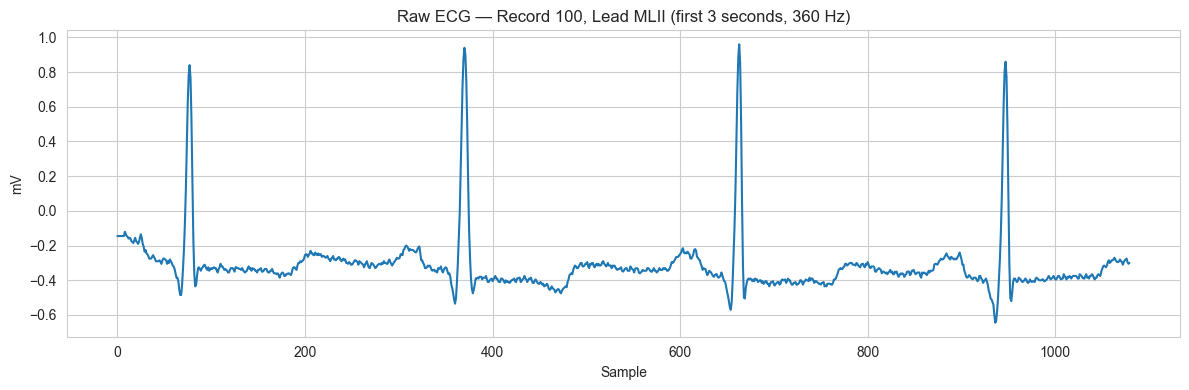

In [65]:
plt.plot(sample_record.p_signal[:1080, 0])
plt.title("Raw ECG — Record 100, Lead MLII (first 3 seconds, 360 Hz)")
plt.xlabel("Sample")
plt.ylabel("mV")
plt.tight_layout()
plt.show()

In [66]:
import os
import glob

record_ids = [
    os.path.splitext(os.path.basename(f))[0]
    for f in glob.glob(os.path.join(DATA_DIR, "*.hea"))
]

print("Number of records:", len(record_ids))
print("First few records:", record_ids[:5])

Number of records: 48
First few records: ['100', '101', '102', '103', '104']


In [67]:
def parse_header_comments(record_id):
    h = wfdb.rdheader(f"{DATA_DIR}/{record_id}")
    age, sex, meds = None, None, None
    if h.comments:
        parts = h.comments[0].split()
        if len(parts) >= 2:
            try:
                age = int(parts[0])
            except ValueError:
                age = None
            sex = parts[1]
        if len(h.comments) > 1:
            meds = h.comments[1]
    return age, sex, meds
meta_rows = []
for rid in record_ids:
    age, sex, meds = parse_header_comments(rid)
    meta_rows.append({"record": rid, "age": age, "sex": sex})  
meta_df = pd.DataFrame(meta_rows)
def age_band(a):
    if pd.isna(a):
        return "Unknown"
    if a < 40: return "<40"
    if a < 60: return "40-59"
    if a < 80: return "60-79"
    return "80+"
meta_df["age_band"] = meta_df["age"].apply(age_band)
print(meta_df[["record", "age_band", "sex"]])
print("\nSex distribution:", meta_df["sex"].value_counts(dropna=False).to_dict())

   record age_band sex
0     100    60-79   M
1     101    60-79   F
2     102      80+   F
3     103      <40   M
4     104    60-79   F
5     105    60-79   F
6     106      <40   F
7     107    60-79   M
8     108      80+   F
9     109    60-79   M
10    111    40-59   F
11    112    40-59   M
12    113      <40   F
13    114    60-79   F
14    115      <40   F
15    116    60-79   M
16    117    60-79   M
17    118    60-79   M
18    119    40-59   F
19    121      80+   F
20    122    40-59   M
21    123    60-79   F
22    124    60-79   M
23    200    60-79   M
24    201    60-79   M
25    202    60-79   M
26    203    40-59   M
27    205    40-59   M
28    207      80+   F
29    208      <40   F
30    209    60-79   M
31    210      80+   M
32    212      <40   F
33    213    60-79   M
34    214    40-59   M
35    215      80+   M
36    217    60-79   M
37    219      <40   M
38    220      80+   F
39    221      80+   M
40    222      80+   F
41    223    60-79   M
42    228  

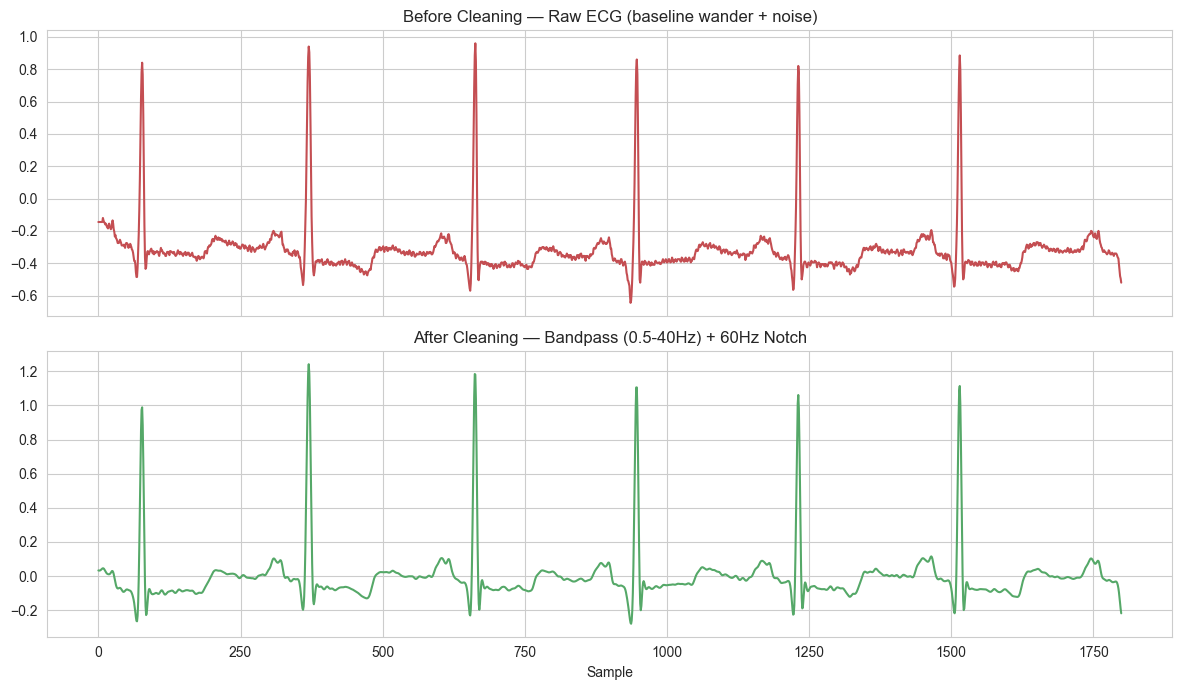

In [68]:
def bandpass_filter(signal, fs, low=0.5, high=40.0, order=4):
    nyq = fs / 2
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, signal)
def notch_filter(signal, fs, freq=60.0, q=30):
    b, a = iirnotch(freq / (fs / 2), q)
    return filtfilt(b, a, signal)
def clean_ecg(signal, fs):
    filtered = bandpass_filter(signal, fs)
    filtered = notch_filter(filtered, fs)
    return filtered
fs = sample_record.fs
mlii_idx = sample_record.sig_name.index("MLII")
raw_segment = sample_record.p_signal[:1800, mlii_idx]
clean_segment = clean_ecg(sample_record.p_signal[:, mlii_idx], fs)[:1800]
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(raw_segment, color="#C44E52")
axes[0].set_title("Before Cleaning — Raw ECG (baseline wander + noise)")
axes[1].plot(clean_segment, color="#55A868")
axes[1].set_title("After Cleaning — Bandpass (0.5-40Hz) + 60Hz Notch")
plt.xlabel("Sample")
plt.tight_layout()
plt.show()

In [69]:
AAMI_MAP = {
    "N": "N", "L": "N", "R": "N", "e": "N", "j": "N",
    "A": "S", "a": "S", "J": "S", "S": "S",
    "V": "V", "E": "V",
    "F": "F",
    "/": "Q", "f": "Q", "Q": "Q",
}
NON_BEAT_SYMBOLS = {"+", "~", "|", '"', "x", "[", "]", "!", "U", "?"}
WINDOW_PRE = 90    
WINDOW_POST = 160  
WINDOW_LEN = WINDOW_PRE + WINDOW_POST
def extract_beats(record_id):
    rec = wfdb.rdrecord(f"{DATA_DIR}/{record_id}")
    ann = wfdb.rdann(f"{DATA_DIR}/{record_id}", "atr")
    lead_idx = rec.sig_name.index("MLII") if "MLII" in rec.sig_name else 0
    signal = clean_ecg(rec.p_signal[:, lead_idx], rec.fs)
    beats, labels, rr_prev, rr_next = [], [], [], []
    samples = ann.sample
    symbols = ann.symbol
    for i, (samp, sym) in enumerate(zip(samples, symbols)):
        if sym not in AAMI_MAP:
            continue
        if samp - WINDOW_PRE < 0 or samp + WINDOW_POST > len(signal):
            continue
        window = signal[samp - WINDOW_PRE: samp + WINDOW_POST]
        beats.append(window)
        labels.append(AAMI_MAP[sym])
        prev_rr = (samp - samples[i - 1]) / rec.fs if i > 0 else np.nan
        next_rr = (samples[i + 1] - samp) / rec.fs if i < len(samples) - 1 else np.nan
        rr_prev.append(prev_rr)
        rr_next.append(next_rr)
    return np.array(beats), np.array(labels), np.array(rr_prev), np.array(rr_next), [record_id] * len(labels)
all_beats, all_labels, all_rr_prev, all_rr_next, all_records = [], [], [], [], []
for rid in record_ids:
    b, l, rp, rn, rec_ids = extract_beats(rid)
    all_beats.append(b)
    all_labels.append(l)
    all_rr_prev.append(rp)
    all_rr_next.append(rn)
    all_records.extend(rec_ids)
X_beats = np.concatenate(all_beats, axis=0)
y_labels = np.concatenate(all_labels, axis=0)
rr_prev = np.concatenate(all_rr_prev, axis=0)
rr_next = np.concatenate(all_rr_next, axis=0)
print("Total beats extracted:", X_beats.shape)
print("Beat window length (samples):", WINDOW_LEN, f"= {WINDOW_LEN/fs:.2f}s at {fs}Hz")

Total beats extracted: (109452, 250)
Beat window length (samples): 250 = 0.69s at 360Hz


In [70]:
label_counts = pd.Series(y_labels).value_counts()
print(label_counts)
print((label_counts / label_counts.sum() * 100).round(2))

N    90594
Q     8040
V     7235
S     2781
F      802
Name: count, dtype: int64
N    82.77
Q     7.35
V     6.61
S     2.54
F     0.73
Name: count, dtype: float64


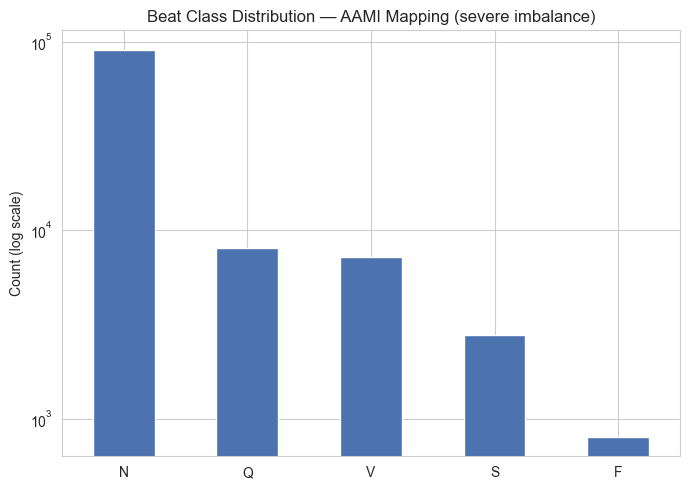

In [71]:
plt.figure(figsize=(7, 5))
label_counts.plot(kind="bar", color="#4C72B0")
plt.title("Beat Class Distribution — AAMI Mapping (severe imbalance)")
plt.ylabel("Count (log scale)")
plt.yscale("log")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

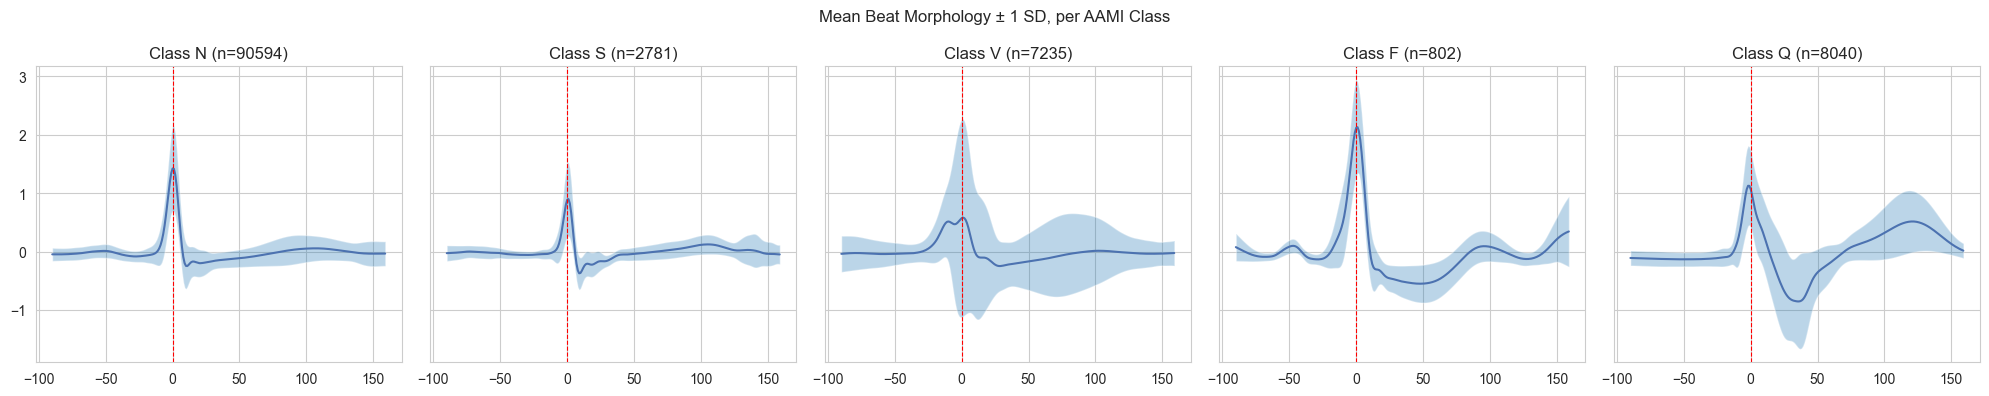

In [72]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for ax, cls in zip(axes, ["N", "S", "V", "F", "Q"]):
    idx = np.where(y_labels == cls)[0]
    if len(idx) == 0:
        continue
    mean_wave = X_beats[idx].mean(axis=0)
    std_wave = X_beats[idx].std(axis=0)
    x_axis = np.arange(-WINDOW_PRE, WINDOW_POST)
    ax.plot(x_axis, mean_wave, color="#4C72B0")
    ax.fill_between(x_axis, mean_wave - std_wave, mean_wave + std_wave, alpha=0.3)
    ax.set_title(f"Class {cls} (n={len(idx)})")
    ax.axvline(0, color="red", linestyle="--", linewidth=0.8)
plt.suptitle("Mean Beat Morphology ± 1 SD, per AAMI Class")
plt.tight_layout()
plt.show()

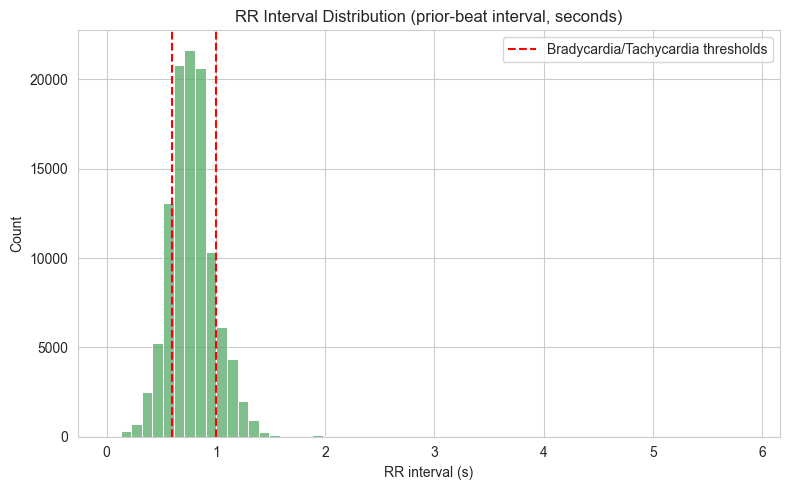

In [73]:
plt.figure(figsize=(8, 5))
sns.histplot(rr_prev[~np.isnan(rr_prev)], bins=60, color="#55A868")
plt.axvline(0.6, color="red", linestyle="--", label="Bradycardia/Tachycardia thresholds")
plt.axvline(1.0, color="red", linestyle="--")
plt.title("RR Interval Distribution (prior-beat interval, seconds)")
plt.xlabel("RR interval (s)")
plt.legend()
plt.tight_layout()
plt.show()

In [74]:
def zscore_normalize(beats):
    mean = beats.mean(axis=1, keepdims=True)
    std = beats.std(axis=1, keepdims=True) + 1e-8
    return (beats - mean) / std
X_beats_norm = zscore_normalize(X_beats)
feat_df = pd.DataFrame({
    "record": all_records,
    "label": y_labels,
    "rr_prev": rr_prev,
    "rr_next": rr_next,
    "beat_amplitude_max": X_beats.max(axis=1),
    "beat_amplitude_min": X_beats.min(axis=1),
    "beat_amplitude_range": X_beats.max(axis=1) - X_beats.min(axis=1),
    "beat_std": X_beats.std(axis=1),
    "beat_energy": (X_beats ** 2).sum(axis=1),
})
feat_df["rr_ratio"] = feat_df["rr_prev"] / feat_df["rr_next"]
feat_df = feat_df.dropna().reset_index(drop=True)  
print(feat_df.describe())

             rr_prev        rr_next  beat_amplitude_max  beat_amplitude_min  \
count  109432.000000  109432.000000       109432.000000       109432.000000   
mean        0.779420       0.777367            1.483931           -0.594289   
std         0.219639       0.217518            0.612758            0.475908   
min         0.030556       0.016667           -0.053172           -3.571107   
25%         0.650000       0.647222            0.981843           -0.754396   
50%         0.758333       0.755556            1.453537           -0.453968   
75%         0.886111       0.883333            1.944183           -0.258154   
max         5.872222       5.872222            4.051931            0.127955   

       beat_amplitude_range       beat_std    beat_energy       rr_ratio  
count         109432.000000  109432.000000  109432.000000  109432.000000  
mean               2.078220       0.342858      36.933559       1.049274  
std                0.834478       0.168812      42.839626      

In [75]:
numeric_feats = ["rr_prev", "rr_next", "rr_ratio", "beat_amplitude_max",
                  "beat_amplitude_min", "beat_amplitude_range", "beat_std", "beat_energy"]
f_scores, p_vals = f_classif(feat_df[numeric_feats], feat_df["label"])
f_score_series = pd.Series(f_scores, index=numeric_feats).sort_values(ascending=False)
print("ANOVA F-scores (feature vs AAMI class):")
print(f_score_series)

ANOVA F-scores (feature vs AAMI class):
beat_energy             9338.385659
beat_std                8030.822044
beat_amplitude_min      7794.825016
rr_prev                 4108.688143
beat_amplitude_range    2015.761113
rr_ratio                1816.493621
beat_amplitude_max      1058.965019
rr_next                  735.626207
dtype: float64


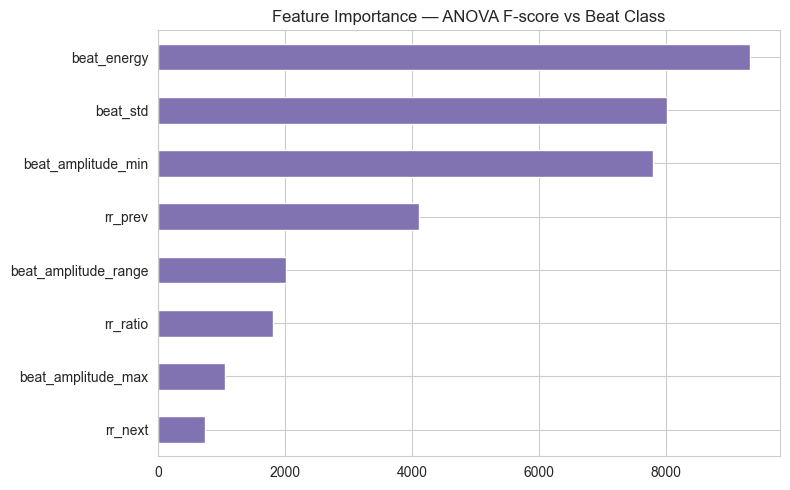

In [76]:
plt.figure(figsize=(8, 5))
f_score_series.plot(kind="barh", color="#8172B2")
plt.title("Feature Importance — ANOVA F-score vs Beat Class")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

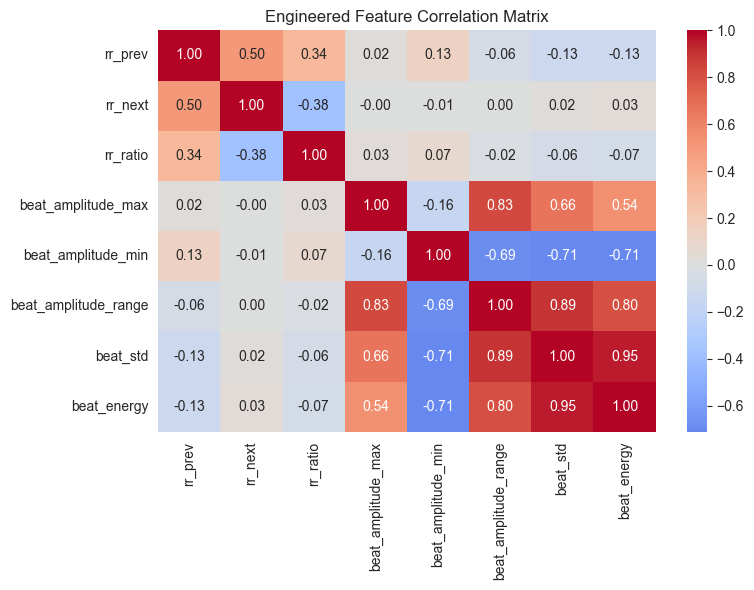

In [77]:
plt.figure(figsize=(8, 6))
sns.heatmap(feat_df[numeric_feats].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Engineered Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [78]:
def augment_beat(beat):
    aug = beat.copy()
    if rng.random() < 0.7:
        aug = aug + rng.normal(0, 0.02, size=aug.shape)          
    if rng.random() < 0.7:
        aug = aug * rng.uniform(0.9, 1.1)
    if rng.random() < 0.5:
        shift = rng.integers(-5, 6)
        aug = np.roll(aug, shift)                                  
    return aug
minority_classes = ["S", "V", "F", "Q"]
target_count = label_counts["N"] // 10
aug_beats, aug_labels = [], []
for cls in minority_classes:
    idx = np.where(y_labels == cls)[0]
    if len(idx) == 0:
        continue
    n_needed = max(0, target_count - len(idx))
    for _ in range(n_needed):
        src = X_beats_norm[rng.choice(idx)]
        aug_beats.append(augment_beat(src))
        aug_labels.append(cls)
if aug_beats:
    aug_beats = np.array(aug_beats)
    aug_labels = np.array(aug_labels)
    print("Augmented beats generated per class:")
    print(pd.Series(aug_labels).value_counts())
else:
    aug_beats, aug_labels = np.empty((0, WINDOW_LEN)), np.empty((0,), dtype=object)
X_beats_final = np.concatenate([X_beats_norm, aug_beats], axis=0)
y_labels_final = np.concatenate([y_labels, aug_labels], axis=0)
print("\nFinal class distribution after augmentation:")
print(pd.Series(y_labels_final).value_counts())

Augmented beats generated per class:
F    8257
S    6278
V    1824
Q    1019
Name: count, dtype: int64

Final class distribution after augmentation:
N    90594
S     9059
V     9059
Q     9059
F     9059
Name: count, dtype: int64


In [79]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels_final)
X_train, X_test, y_train, y_test = train_test_split(
    X_beats_final, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)
X_train_tensor = X_train.reshape(-1, WINDOW_LEN, 1).astype(np.float32)
X_test_tensor = X_test.reshape(-1, WINDOW_LEN, 1).astype(np.float32)
print("Train tensor shape:", X_train_tensor.shape)
print("Test tensor shape:", X_test_tensor.shape)
print("Label classes:", dict(zip(le.classes_, range(len(le.classes_)))))
print("Train class balance:", pd.Series(y_train).value_counts(normalize=True).round(3).to_dict())

Train tensor shape: (101464, 250, 1)
Test tensor shape: (25366, 250, 1)
Label classes: {np.str_('F'): 0, np.str_('N'): 1, np.str_('Q'): 2, np.str_('S'): 3, np.str_('V'): 4}
Train class balance: {1: 0.714, 2: 0.071, 4: 0.071, 0: 0.071, 3: 0.071}
